In [30]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import networkx as nx



In [31]:
file_path = "archive/data/events/267368.json"
df = pd.read_json(file_path)

In [32]:
df.head()

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,...,clearance,foul_won,ball_recovery,block,shot,goalkeeper,foul_committed,50_50,miscontrol,substitution
0,49eb9619-10e5-4ed7-aada-53411aaa31a0,1,1,2026-06-30 00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 217, 'name': 'Barcelona'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1a9a69df-de1a-440a-95a4-636e1ce56fca,2,1,2026-06-30 00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 217, 'name': 'Barcelona'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,b48721cf-7270-4142-8073-78ff4914bd0b,3,1,2026-06-30 00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 217, 'name': 'Barcelona'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,874f156e-4c7a-40e7-be64-e74cf104f5d2,4,1,2026-06-30 00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 217, 'name': 'Barcelona'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,421ea6f8-ff67-4682-95de-04c14e73f838,5,1,2026-06-30 00:00:01.501,0,1,"{'id': 30, 'name': 'Pass'}",2,"{'id': 217, 'name': 'Barcelona'}","{'id': 9, 'name': 'From Kick Off'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
df.columns

Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'type',
       'possession', 'possession_team', 'play_pattern', 'team', 'duration',
       'tactics', 'related_events', 'player', 'position', 'location', 'pass',
       'carry', 'under_pressure', 'ball_receipt', 'off_camera', 'duel', 'out',
       'counterpress', 'interception', 'dribble', 'clearance', 'foul_won',
       'ball_recovery', 'block', 'shot', 'goalkeeper', 'foul_committed',
       '50_50', 'miscontrol', 'substitution'],
      dtype='str')

In [34]:
print(df['team'].head())


0     {'id': 217, 'name': 'Barcelona'}
1    {'id': 218, 'name': 'Real Betis'}
2     {'id': 217, 'name': 'Barcelona'}
3    {'id': 218, 'name': 'Real Betis'}
4     {'id': 217, 'name': 'Barcelona'}
Name: team, dtype: object


In [35]:
barcelona_data = df[df['team'] == 'Barcelona']

# Display the first few rows of Barcelona's data
print(barcelona_data.head())

Empty DataFrame
Columns: [id, index, period, timestamp, minute, second, type, possession, possession_team, play_pattern, team, duration, tactics, related_events, player, position, location, pass, carry, under_pressure, ball_receipt, off_camera, duel, out, counterpress, interception, dribble, clearance, foul_won, ball_recovery, block, shot, goalkeeper, foul_committed, 50_50, miscontrol, substitution]
Index: []

[0 rows x 37 columns]


In [36]:
# Check the number of non-null values in the 'team' column
print(df['team'].notnull().sum())

# Display some of the 'team' column data to ensure it's there
print(df['team'].head())


3834
0     {'id': 217, 'name': 'Barcelona'}
1    {'id': 218, 'name': 'Real Betis'}
2     {'id': 217, 'name': 'Barcelona'}
3    {'id': 218, 'name': 'Real Betis'}
4     {'id': 217, 'name': 'Barcelona'}
Name: team, dtype: object


In [37]:
# Display the first few rows of the DataFrame to inspect the structure
print(df.head())


                                     id  index  period  \
0  49eb9619-10e5-4ed7-aada-53411aaa31a0      1       1   
1  1a9a69df-de1a-440a-95a4-636e1ce56fca      2       1   
2  b48721cf-7270-4142-8073-78ff4914bd0b      3       1   
3  874f156e-4c7a-40e7-be64-e74cf104f5d2      4       1   
4  421ea6f8-ff67-4682-95de-04c14e73f838      5       1   

                timestamp  minute  second                               type  \
0 2026-06-30 00:00:00.000       0       0  {'id': 35, 'name': 'Starting XI'}   
1 2026-06-30 00:00:00.000       0       0  {'id': 35, 'name': 'Starting XI'}   
2 2026-06-30 00:00:00.000       0       0   {'id': 18, 'name': 'Half Start'}   
3 2026-06-30 00:00:00.000       0       0   {'id': 18, 'name': 'Half Start'}   
4 2026-06-30 00:00:01.501       0       1         {'id': 30, 'name': 'Pass'}   

   possession                   possession_team  \
0           1  {'id': 217, 'name': 'Barcelona'}   
1           1  {'id': 217, 'name': 'Barcelona'}   
2           1  {'

In [38]:
# Check the unique team names in your dataset
print(df['team'].apply(lambda x: x['name'] if pd.notnull(x) else None).unique())


<ArrowStringArray>
['Barcelona', 'Real Betis']
Length: 2, dtype: str


In [39]:
# Extract the team name from the 'team' column
df['team_name'] = df['team'].apply(lambda x: x['name'] if pd.notnull(x) else None)

# Filter the data for the specific team (e.g., 'Barcelona')
barcelona_data = df[df['team_name'] == 'Barcelona']

# Display the first few rows of the filtered DataFrame
print(barcelona_data.head())


                                     id  index  period  \
0  49eb9619-10e5-4ed7-aada-53411aaa31a0      1       1   
2  b48721cf-7270-4142-8073-78ff4914bd0b      3       1   
4  421ea6f8-ff67-4682-95de-04c14e73f838      5       1   
5  679f4a72-35d9-4f3c-8d56-d7948c4abcc4      6       1   
6  f76c6295-68ae-4669-a21b-8549f5c0ce0b      7       1   

                timestamp  minute  second  \
0 2026-06-30 00:00:00.000       0       0   
2 2026-06-30 00:00:00.000       0       0   
4 2026-06-30 00:00:01.501       0       1   
5 2026-06-30 00:00:02.572       0       2   
6 2026-06-30 00:00:02.572       0       2   

                                  type  possession  \
0    {'id': 35, 'name': 'Starting XI'}           1   
2     {'id': 18, 'name': 'Half Start'}           1   
4           {'id': 30, 'name': 'Pass'}           2   
5  {'id': 42, 'name': 'Ball Receipt*'}           2   
6          {'id': 43, 'name': 'Carry'}           2   

                    possession_team                    

In [40]:
# Count the number of rows matching the filter criteria
print(df[df['team_name'] == 'Barcelona'].shape)


(2283, 38)


In [41]:
# Inspect the structure of a specific row to understand the nested data
print(df.iloc[0])


id                              49eb9619-10e5-4ed7-aada-53411aaa31a0
index                                                              1
period                                                             1
timestamp                                        2026-06-30 00:00:00
minute                                                             0
second                                                             0
type                               {'id': 35, 'name': 'Starting XI'}
possession                                                         1
possession_team                     {'id': 217, 'name': 'Barcelona'}
play_pattern                       {'id': 1, 'name': 'Regular Play'}
team                                {'id': 217, 'name': 'Barcelona'}
duration                                                         0.0
tactics            {'formation': 433, 'lineup': [{'player': {'id'...
related_events                                                   NaN
player                            

In [42]:
# Extract relevant events where player positions are important (e.g., Pass, Shot, etc.)
relevant_events = df[df['type'].apply(lambda x: x['name']).isin(['Pass', 'Shot'])]

# Filter data for Barcelona's events
barcelona_events = relevant_events[relevant_events['team_name'] == 'Barcelona']

# Extract player positions and relevant data
barcelona_events[['player', 'position', 'location']].head()


,player,position,location
4,"{'id': 3385, 'name': 'Alexis Alejandro Sánchez...","{'id': 17, 'name': 'Right Wing'}","[60.0, 40.0]"
7,"{'id': 5203, 'name': 'Sergio Busquets i Burgos'}","{'id': 10, 'name': 'Center Defensive Midfield'}","[47.1, 39.9]"
10,"{'id': 20131, 'name': 'Xavier Hernández Creus'}","{'id': 13, 'name': 'Right Center Midfield'}","[49.8, 51.5]"
13,"{'id': 5506, 'name': 'Javier Alejandro Mascher...","{'id': 5, 'name': 'Left Center Back'}","[43.4, 31.6]"
16,"{'id': 5216, 'name': 'Andrés Iniesta Luján'}","{'id': 15, 'name': 'Left Center Midfield'}","[63.5, 27.7]"


创造新的Dataframe，Location被分开为x、y两列。

In [43]:
# Split the 'location' column into 'x' and 'y' coordinates
# Extract x and y coordinates safely
barcelona_events.loc[:, ['x', 'y']] = pd.DataFrame(barcelona_events['location'].tolist(), index=barcelona_events.index)


# Display the first few rows of the updated DataFrame
print(barcelona_events[['player', 'position', 'x', 'y']].head())


                                               player  \
4   {'id': 3385, 'name': 'Alexis Alejandro Sánchez...   
7    {'id': 5203, 'name': 'Sergio Busquets i Burgos'}   
10    {'id': 20131, 'name': 'Xavier Hernández Creus'}   
13  {'id': 5506, 'name': 'Javier Alejandro Mascher...   
16       {'id': 5216, 'name': 'Andrés Iniesta Luján'}   

                                           position   x   y  
4                  {'id': 17, 'name': 'Right Wing'} NaN NaN  
7   {'id': 10, 'name': 'Center Defensive Midfield'} NaN NaN  
10      {'id': 13, 'name': 'Right Center Midfield'} NaN NaN  
13            {'id': 5, 'name': 'Left Center Back'} NaN NaN  
16       {'id': 15, 'name': 'Left Center Midfield'} NaN NaN  


In [44]:
# Check for missing values in critical columns
print(barcelona_events[['player', 'location', 'x', 'y']].isnull().sum())

# Display the first few rows to ensure proper extraction
print(barcelona_events.head())



player        0
location      0
x           666
y           666
dtype: int64
                                      id  index  period  \
4   421ea6f8-ff67-4682-95de-04c14e73f838      5       1   
7   3cac804f-e566-4606-9611-8b12b8b73722      8       1   
10  9c8edf8d-7b6f-443a-8767-a72b05922b2d     11       1   
13  79aa2803-7ab2-4dc4-80da-4614d4297e1b     14       1   
16  791a0407-4e26-480e-945e-586b0dbac82d     17       1   

                 timestamp  minute  second                        type  \
4  2026-06-30 00:00:01.501       0       1  {'id': 30, 'name': 'Pass'}   
7  2026-06-30 00:00:02.874       0       2  {'id': 30, 'name': 'Pass'}   
10 2026-06-30 00:00:05.965       0       5  {'id': 30, 'name': 'Pass'}   
13 2026-06-30 00:00:08.424       0       8  {'id': 30, 'name': 'Pass'}   
16 2026-06-30 00:00:13.906       0      13  {'id': 30, 'name': 'Pass'}   

    possession                   possession_team  \
4            2  {'id': 217, 'name': 'Barcelona'}   
7            2  {'i

In [45]:
print(barcelona_events.columns)


Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'type',
       'possession', 'possession_team', 'play_pattern', 'team', 'duration',
       'tactics', 'related_events', 'player', 'position', 'location', 'pass',
       'carry', 'under_pressure', 'ball_receipt', 'off_camera', 'duel', 'out',
       'counterpress', 'interception', 'dribble', 'clearance', 'foul_won',
       'ball_recovery', 'block', 'shot', 'goalkeeper', 'foul_committed',
       '50_50', 'miscontrol', 'substitution', 'team_name', 'x', 'y'],
      dtype='str')


In [46]:
# Display the type of each entry in the 'player' column
print(barcelona_events['player'].apply(type).value_counts())



player
<class 'dict'>    666
Name: count, dtype: int64


In [47]:
# Find entries that are dictionaries or other non-string types
non_string_entries = barcelona_events[~barcelona_events['player'].apply(lambda x: isinstance(x, str))]
print(non_string_entries)


                                        id  index  period  \
4     421ea6f8-ff67-4682-95de-04c14e73f838      5       1   
7     3cac804f-e566-4606-9611-8b12b8b73722      8       1   
10    9c8edf8d-7b6f-443a-8767-a72b05922b2d     11       1   
13    79aa2803-7ab2-4dc4-80da-4614d4297e1b     14       1   
16    791a0407-4e26-480e-945e-586b0dbac82d     17       1   
...                                    ...    ...     ...   
3794  cab5c6d8-8631-44d6-98a3-51c1202dcd97   3795       2   
3802  19ea9156-4223-4162-bc60-d7687b7a5189   3803       2   
3805  116f3bfc-1473-4e46-8c62-0448c15b0b38   3806       2   
3808  48b7a176-42b5-4969-96c8-8d6509763d7f   3809       2   
3811  d988ad95-77b0-4342-83c1-5c7e80b96771   3812       2   

                   timestamp  minute  second                        type  \
4    2026-06-30 00:00:01.501       0       1  {'id': 30, 'name': 'Pass'}   
7    2026-06-30 00:00:02.874       0       2  {'id': 30, 'name': 'Pass'}   
10   2026-06-30 00:00:05.965       0   

In [48]:
# Convert all non-string values in 'player' column to strings
barcelona_events['player'] = barcelona_events['player'].apply(lambda x: str(x) if not isinstance(x, str) else x)


In [49]:
# Check unique values and types in the 'player' column again
print(barcelona_events['player'].apply(type).value_counts())
print(barcelona_events['player'].unique())


player
<class 'str'>    666
Name: count, dtype: int64
<ArrowStringArray>
['{'id': 3385, 'name': 'Alexis Alejandro Sánchez Sánchez'}',
         '{'id': 5203, 'name': 'Sergio Busquets i Burgos'}',
          '{'id': 20131, 'name': 'Xavier Hernández Creus'}',
      '{'id': 5506, 'name': 'Javier Alejandro Mascherano'}',
             '{'id': 5216, 'name': 'Andrés Iniesta Luján'}',
  '{'id': 3958, 'name': 'Pedro Eliezer Rodríguez Ledesma'}',
           '{'id': 22102, 'name': 'Adriano Correia Claro'}',
              '{'id': 7068, 'name': 'Marc Bartra Aregall'}',
            '{'id': 4324, 'name': 'Daniel Alves da Silva'}',
   '{'id': 5503, 'name': 'Lionel Andrés Messi Cuccittini'}',
      '{'id': 26005, 'name': 'José Manuel Pinto Colorado'}',
        '{'id': 3478, 'name': 'Francesc Fàbregas i Soler'}',
    '{'id': 4320, 'name': 'Neymar da Silva Santos Junior'}',
  '{'id': 27053, 'name': 'Alexandre Dimitri Song-Billong'}']
Length: 14, dtype: str


In [50]:
# Group by player name to calculate average positions
formation = barcelona_events.groupby('player').agg({'x': 'mean', 'y': 'mean'}).reset_index()

# Display the formation data
print(formation)


                                               player   x   y
0     {'id': 20131, 'name': 'Xavier Hernández Creus'} NaN NaN
1      {'id': 22102, 'name': 'Adriano Correia Claro'} NaN NaN
2   {'id': 26005, 'name': 'José Manuel Pinto Color... NaN NaN
3   {'id': 27053, 'name': 'Alexandre Dimitri Song-... NaN NaN
4   {'id': 3385, 'name': 'Alexis Alejandro Sánchez... NaN NaN
5   {'id': 3478, 'name': 'Francesc Fàbregas i Soler'} NaN NaN
6   {'id': 3958, 'name': 'Pedro Eliezer Rodríguez ... NaN NaN
7   {'id': 4320, 'name': 'Neymar da Silva Santos J... NaN NaN
8       {'id': 4324, 'name': 'Daniel Alves da Silva'} NaN NaN
9    {'id': 5203, 'name': 'Sergio Busquets i Burgos'} NaN NaN
10       {'id': 5216, 'name': 'Andrés Iniesta Luján'} NaN NaN
11  {'id': 5503, 'name': 'Lionel Andrés Messi Cucc... NaN NaN
12  {'id': 5506, 'name': 'Javier Alejandro Mascher... NaN NaN
13        {'id': 7068, 'name': 'Marc Bartra Aregall'} NaN NaN


In [51]:
# Inspect the 'location' column to understand its format
print(barcelona_events['location'].head())


4     [60.0, 40.0]
7     [47.1, 39.9]
10    [49.8, 51.5]
13    [43.4, 31.6]
16    [63.5, 27.7]
Name: location, dtype: object


In [52]:
# Check for rows where 'location' is a list of length 2
valid_locations = barcelona_events['location'].apply(lambda x: isinstance(x, list) and len(x) == 2)
barcelona_events_valid = barcelona_events[valid_locations]



In [53]:
# Ensure 'location' column is a list and has length 2
valid_locations = barcelona_events['location'].apply(lambda x: isinstance(x, list) and len(x) == 2)
barcelona_events_valid = barcelona_events[valid_locations].copy()  # Make a copy of the filtered DataFrame

# Extract coordinates for valid entries
coordinates = pd.DataFrame(barcelona_events_valid['location'].tolist(), index=barcelona_events_valid.index, columns=['x', 'y'])
barcelona_events_valid.loc[:, ['x', 'y']] = coordinates


In [54]:
# Handle invalid rows if needed (e.g., fill with default values or drop)
barcelona_events_invalid = barcelona_events[~valid_locations].copy()  # Make a copy of the invalid DataFrame
barcelona_events_invalid[['x', 'y']] = None  # or some default values


In [55]:
# Recalculate average positions for valid data
formation = barcelona_events_valid.groupby('player').agg({'x': 'mean', 'y': 'mean'}).reset_index()

# Display the updated formation data
print(formation)


                                               player           x          y
0     {'id': 20131, 'name': 'Xavier Hernández Creus'}   64.060000  43.815294
1      {'id': 22102, 'name': 'Adriano Correia Claro'}   64.980000  12.804615
2   {'id': 26005, 'name': 'José Manuel Pinto Color...    9.490323  42.025806
3   {'id': 27053, 'name': 'Alexandre Dimitri Song-...   73.820000  45.920000
4   {'id': 3385, 'name': 'Alexis Alejandro Sánchez...   68.558824  57.652941
5   {'id': 3478, 'name': 'Francesc Fàbregas i Soler'}   87.312500  24.612500
6   {'id': 3958, 'name': 'Pedro Eliezer Rodríguez ...   78.700000  16.535135
7   {'id': 4320, 'name': 'Neymar da Silva Santos J...  101.533333  14.433333
8       {'id': 4324, 'name': 'Daniel Alves da Silva'}   68.031746  65.509524
9    {'id': 5203, 'name': 'Sergio Busquets i Burgos'}   54.241333  40.989333
10       {'id': 5216, 'name': 'Andrés Iniesta Luján'}   68.019672  27.791803
11  {'id': 5503, 'name': 'Lionel Andrés Messi Cucc...   81.593443  52.563934

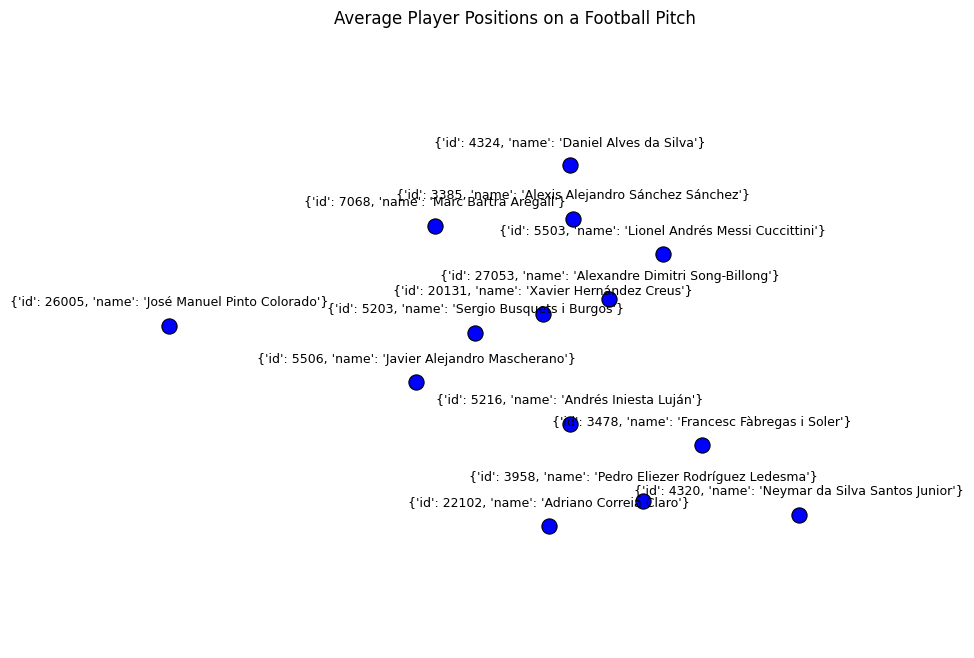

In [56]:
# Plot average player positions on a standard football pitch
def draw_pitch(ax, pitch_color='#a8d08d', line_color='white'):
    ax.set_facecolor(pitch_color)
    ax.plot([0, 0], [0, 80], color=line_color)
    ax.plot([120, 120], [0, 80], color=line_color)
    ax.plot([0, 120], [0, 0], color=line_color)
    ax.plot([0, 120], [80, 80], color=line_color)
    ax.plot([60, 60], [0, 80], color=line_color)
    ax.add_patch(plt.Rectangle((0, 21), 18, 38, fill=False, edgecolor=line_color, linewidth=1.5))
    ax.add_patch(plt.Rectangle((102, 21), 18, 38, fill=False, edgecolor=line_color, linewidth=1.5))
    ax.add_patch(plt.Rectangle((0, 30), 6, 20, fill=False, edgecolor=line_color, linewidth=1.5))
    ax.add_patch(plt.Rectangle((114, 30), 6, 20, fill=False, edgecolor=line_color, linewidth=1.5))
    ax.add_patch(plt.Circle((60, 40), 9.15, fill=False, edgecolor=line_color, linewidth=1.5))
    ax.add_patch(plt.Circle((60, 40), 0.5, color=line_color))
    ax.add_patch(plt.Circle((12, 40), 0.5, color=line_color))
    ax.add_patch(plt.Circle((108, 40), 0.5, color=line_color))
    ax.set_xlim(-5, 125)
    ax.set_ylim(-5, 85)
    ax.set_aspect('equal')
    ax.axis('off')

fig, ax = plt.subplots(figsize=(12, 8))
draw_pitch(ax)
ax.scatter(formation['x'], formation['y'], s=120, color='blue', edgecolors='black', linewidth=0.8, zorder=5)
for i, row in formation.iterrows():
    ax.text(row['x'], row['y'] + 2.5, row['player'], fontsize=9, ha='center', va='bottom', color='black', zorder=6)

ax.set_title('Average Player Positions on a Football Pitch')
plt.show()


In [57]:
import plotly.express as px

# Plotly scatter plot with player names
fig = px.scatter(formation, x='x', y='y', text='player', color='player',
                 title='Average Player Positions by Team',
                 labels={'x': 'X Position', 'y': 'Y Position'})

# Update the layout
fig.update_traces(textposition='top center')
fig.update_layout(xaxis_title='X Position',
                  yaxis_title='Y Position',
                  xaxis_range=[0, 100],
                  yaxis_range=[0, 100])
fig.show()


c:\Users\Liuhy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



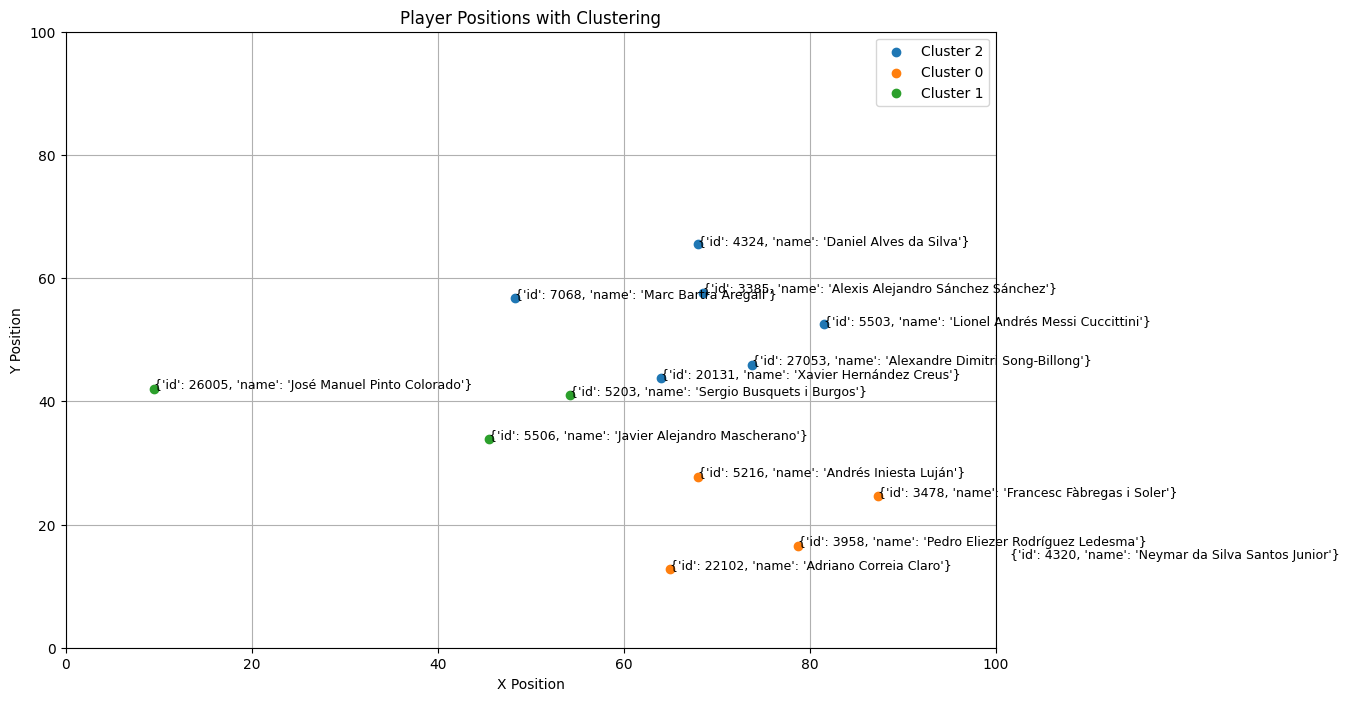

In [58]:
from sklearn.cluster import KMeans

# Assume we want to find 3 clusters
kmeans = KMeans(n_clusters=3, random_state=0).fit(formation[['x', 'y']])
formation['cluster'] = kmeans.labels_

plt.figure(figsize=(12, 8))
for cluster in formation['cluster'].unique():
    cluster_data = formation[formation['cluster'] == cluster]
    plt.scatter(cluster_data['x'], cluster_data['y'], marker='o', label=f'Cluster {cluster}')

    # Annotate points with player names
    for i, row in cluster_data.iterrows():
        plt.text(row['x'], row['y'], row['player'], fontsize=9)

# Set plot labels
plt.title('Player Positions with Clustering')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.grid(True)
plt.legend()
plt.show()
